<a href="https://colab.research.google.com/github/jhonn18git/inteligencia-artificial-1-ia/blob/main/laboratorios/lab3/lab_3_regresion_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación del laboratorio – Regresión logística para clasificación de eventos

En este laboratorio se aplicó un modelo de regresión logística para resolver un problema de clasificación binaria utilizando un dataset de eventos de física de partículas. Este dataset contiene múltiples variables que describen propiedades medidas por detectores de partículas durante diferentes eventos experimentales.

El objetivo principal del modelo es clasificar cada evento como señal o fondo. En el contexto de la física de partículas, una señal representa un evento que corresponde a un fenómeno físico relevante que se desea detectar, mientras que el fondo corresponde a ruido o eventos que no son de interés para el análisis.

El dataset utilizado contiene numerosas características numéricas que describen diferentes propiedades físicas de los eventos. Estas variables se utilizan como características de entrada del modelo, mientras que la variable objetivo es:

Label: indica si el evento corresponde a señal (s) o fondo (b).

Para poder entrenar el modelo, primero se realizó la preparación de los datos. En esta etapa se cargó el dataset utilizando la librería Pandas y se eliminaron los registros que contenían valores faltantes para evitar errores durante el entrenamiento. Posteriormente se separaron las variables de entrada (X) y la variable objetivo (y).

Debido a que los algoritmos de aprendizaje automático funcionan mejor cuando las variables están en escalas similares, se aplicó un proceso de normalización de características, el cual consiste en restar la media de cada variable y dividir por su desviación estándar. Esto ayuda a que el algoritmo de entrenamiento sea más estable y converja más rápidamente.

Después de preparar los datos, el dataset se dividió en dos subconjuntos:

80% de los datos para entrenamiento, utilizados para que el modelo aprenda los patrones de los datos.

20% de los datos para prueba, utilizados para evaluar qué tan bien funciona el modelo con datos que no ha visto anteriormente.

El modelo utilizado fue regresión logística, la cual utiliza la función sigmoide para convertir el resultado del modelo en una probabilidad entre 0 y 1. Esta probabilidad representa la posibilidad de que un evento pertenezca a la clase señal. Si la probabilidad es mayor o igual a 0.5, el evento se clasifica como señal; en caso contrario, se clasifica como fondo.

Durante el entrenamiento se optimizan los parámetros del modelo (theta) utilizando un método de optimización que minimiza la función de costo de regresión logística. Esta función mide la diferencia entre las predicciones del modelo y las etiquetas reales del dataset. A medida que el algoritmo ajusta los parámetros, el modelo aprende a separar correctamente los eventos de señal y fondo.

Posteriormente se evaluó el desempeño del modelo calculando la precisión de clasificación, comparando las predicciones del modelo con los valores reales del dataset tanto en los datos de entrenamiento como en los datos de prueba.

También se realizaron diferentes visualizaciones de los datos, utilizando gráficos de dispersión donde cada punto representa un evento del dataset. En estos gráficos se pueden observar las diferencias entre los eventos clasificados como señal y fondo, así como la frontera de decisión del modelo, que representa la línea que separa ambas clases.

Finalmente, el modelo entrenado se utilizó para realizar predicciones sobre nuevos eventos, demostrando cómo la regresión logística puede utilizarse para resolver problemas de clasificación en conjuntos de datos reales.

In [1]:

# Librería para cálculos numéricos y álgebra lineal
import numpy as np

# Librería para manejo de datasets
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot as plt

# Librería para optimización
from scipy import optimize

# Mostrar gráficos dentro del notebook
%matplotlib inline

In [2]:
# Esta parte permite acceder a archivos almacenados en Google Drive
# desde Google Colab

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
# Cargamos el dataset desde Google Drive
data = pd.read_csv('/content/drive/MyDrive/colab/lab3/Particle Physics Event Classification.csv')

# Mostramos las primeras filas para observar la estructura de los datos
print("Primeras filas del dataset:")
display(data.head())

# Mostramos las dimensiones del dataset
print("Dimensiones del dataset (filas, columnas):")
print(data.shape)

Primeras filas del dataset:


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


Dimensiones del dataset (filas, columnas):
(250000, 33)


In [4]:
# Eliminamos filas que tengan valores faltantes
# Esto evita errores durante el entrenamiento del modelo

data = data.dropna()

print("Dataset después de eliminar valores faltantes:")
print(data.shape)

Dataset después de eliminar valores faltantes:
(250000, 33)


In [6]:
# SEPARACIÓN DE VARIABLES

# X contiene todas las características del evento
# eliminamos la columna Label porque es la etiqueta

X = data.drop(columns=['Label']).values

# y contiene la variable objetivo
# convertimos las etiquetas:
# 's' (signal) -> 1
# 'b' (background) -> 0

y = data['Label'].apply(lambda x: 1 if x == 's' else 0).values

# número total de ejemplos
m = y.size

print("Cantidad de ejemplos en el dataset:", m)

print("Primeros datos de X:")
print(X[:5])

Cantidad de ejemplos en el dataset: 250000
Primeros datos de X:
[[ 1.00000000e+05  1.38470000e+02  5.16550000e+01  9.78270000e+01
   2.79800000e+01  9.10000000e-01  1.24711000e+02  2.66600000e+00
   3.06400000e+00  4.19280000e+01  1.97760000e+02  1.58200000e+00
   1.39600000e+00  2.00000000e-01  3.26380000e+01  1.01700000e+00
   3.81000000e-01  5.16260000e+01  2.27300000e+00 -2.41400000e+00
   1.68240000e+01 -2.77000000e-01  2.58733000e+02  2.00000000e+00
   6.74350000e+01  2.15000000e+00  4.44000000e-01  4.60620000e+01
   1.24000000e+00 -2.47500000e+00  1.13497000e+02  2.65331100e-03]
 [ 1.00001000e+05  1.60937000e+02  6.87680000e+01  1.03235000e+02
   4.81460000e+01 -9.99000000e+02 -9.99000000e+02 -9.99000000e+02
   3.47300000e+00  2.07800000e+00  1.25157000e+02  8.79000000e-01
   1.41400000e+00 -9.99000000e+02  4.20140000e+01  2.03900000e+00
  -3.01100000e+00  3.69180000e+01  5.01000000e-01  1.03000000e-01
   4.47040000e+01 -1.91600000e+00  1.64546000e+02  1.00000000e+00
   4.622600

In [7]:
# NORMALIZACIÓN DE CARACTERÍSTICAS

def normalizar_caracteristicas(X):

    """
    Esta función normaliza cada característica
    para que tenga media 0 y desviación estándar 1.

    Esto es importante porque algunas variables
    pueden tener escalas muy diferentes.
    """

    # media de cada columna
    mu = np.mean(X, axis=0)

    # desviación estándar de cada columna
    sigma = np.std(X, axis=0)

    # normalización
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


# aplicamos la normalización
X_norm, mu, sigma = normalizar_caracteristicas(X)

print("Media de las variables (primeras):", mu[:5])
print("Desviación estándar (primeras):", sigma[:5])

Media de las variables (primeras): [ 2.24999500e+05 -4.90230794e+01  4.92398193e+01  8.11819816e+01
  5.78959617e+01]
Desviación estándar (primeras): [7.21687836e+04 4.06344834e+02 3.53448149e+01 4.08286089e+01
 6.36555543e+01]


In [8]:
# AGREGAR TÉRMINO INDEPENDIENTE (BIAS)

# agregamos una columna de 1s al inicio de X
# esto corresponde al parámetro theta_0 del modelo

X_ready = np.concatenate([np.ones((m,1)), X_norm], axis=1)

print("Shape de X_ready:", X_ready.shape)

Shape de X_ready: (250000, 33)


In [9]:
# DIVISIÓN DE DATOS

# Para validar el modelo usamos:
# 80% datos de entrenamiento
# 20% datos de prueba

split = int(0.8 * m)

# datos de entrenamiento
X_train = X_ready[:split]
y_train = y[:split]

# datos de prueba
X_test = X_ready[split:]
y_test = y[split:]

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (200000, 33)
Datos de prueba: (50000, 33)


In [10]:
# FUNCIÓN SIGMOIDE

def sigmoid(z):

    """
    La función sigmoide transforma cualquier número
    en una probabilidad entre 0 y 1.
    """

    return 1 / (1 + np.exp(-z))

In [11]:
# FUNCIÓN DE COSTO Y GRADIENTE

def costFunction(theta, X, y):

    # número de ejemplos
    m = y.size

    # hipótesis del modelo
    h = sigmoid(np.dot(X, theta))

    # función de costo de regresión logística
    J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))

    # cálculo del gradiente
    grad = (1/m) * np.dot(X.T, (h - y))

    return J, grad


In [12]:
# ENTRENAMIENTO DEL MODELO

# inicializamos theta en ceros
initial_theta = np.zeros(X_train.shape[1])

# usamos scipy para minimizar la función de costo
res = optimize.minimize(
    fun=costFunction,
    x0=initial_theta,
    args=(X_train, y_train),
    jac=True,
    method='TNC',
    options={'maxiter':300}
)

# parámetros finales del modelo
theta = res.x

print("Theta calculado (primeros valores):")
print(theta[:10])

/tmp/ipykernel_320/450059537.py:7: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(
/tmp/ipykernel_320/2080047589.py:12: RuntimeWarning: divide by zero encountered in log
  J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
/tmp/ipykernel_320/2080047589.py:12: RuntimeWarning: invalid value encountered in multiply
  J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))


Theta calculado (primeros valores):
[-3.86171182  0.11876662 -0.14380217 -1.21985762 -0.40035086  0.51875932
 -0.09401775  1.32676242 -0.1209722   1.18761707]


In [13]:
# FUNCIÓN DE PREDICCIÓN

def predict(theta, X):

    """
    Predice si un evento es señal o fondo.
    """

    return np.round(sigmoid(np.dot(X, theta)))

In [14]:
# EVALUACIÓN DEL MODELO EN ENTRENAMIENTO

pred_train = predict(theta, X_train)

accuracy_train = np.mean(pred_train == y_train) * 100

print("Precisión en entrenamiento:", accuracy_train,"%")

Precisión en entrenamiento: 90.2185 %


In [15]:
# EVALUACIÓN DEL MODELO EN PRUEBA

pred_test = predict(theta, X_test)

accuracy_test = np.mean(pred_test == y_test) * 100

print("Precisión en prueba:", accuracy_test,"%")

Precisión en prueba: 89.812 %


In [16]:

# MOSTRAR 100 PREDICCIONES DEL MODELO

print("Primeras 100 predicciones del modelo:\n")

for i in range(100):

    print(
        "Ejemplo", i+1,
        "| Real:", y_test[i],
        "| Predicho:", int(pred_test[i])
    )

Primeras 100 predicciones del modelo:

Ejemplo 1 | Real: 0 | Predicho: 0
Ejemplo 2 | Real: 0 | Predicho: 0
Ejemplo 3 | Real: 1 | Predicho: 0
Ejemplo 4 | Real: 0 | Predicho: 0
Ejemplo 5 | Real: 0 | Predicho: 0
Ejemplo 6 | Real: 1 | Predicho: 1
Ejemplo 7 | Real: 0 | Predicho: 0
Ejemplo 8 | Real: 0 | Predicho: 0
Ejemplo 9 | Real: 0 | Predicho: 0
Ejemplo 10 | Real: 1 | Predicho: 1
Ejemplo 11 | Real: 0 | Predicho: 0
Ejemplo 12 | Real: 0 | Predicho: 0
Ejemplo 13 | Real: 0 | Predicho: 0
Ejemplo 14 | Real: 0 | Predicho: 0
Ejemplo 15 | Real: 0 | Predicho: 0
Ejemplo 16 | Real: 1 | Predicho: 1
Ejemplo 17 | Real: 0 | Predicho: 0
Ejemplo 18 | Real: 0 | Predicho: 0
Ejemplo 19 | Real: 0 | Predicho: 0
Ejemplo 20 | Real: 0 | Predicho: 0
Ejemplo 21 | Real: 1 | Predicho: 1
Ejemplo 22 | Real: 0 | Predicho: 0
Ejemplo 23 | Real: 0 | Predicho: 0
Ejemplo 24 | Real: 1 | Predicho: 1
Ejemplo 25 | Real: 0 | Predicho: 0
Ejemplo 26 | Real: 0 | Predicho: 0
Ejemplo 27 | Real: 0 | Predicho: 0
Ejemplo 28 | Real: 0 | Pr

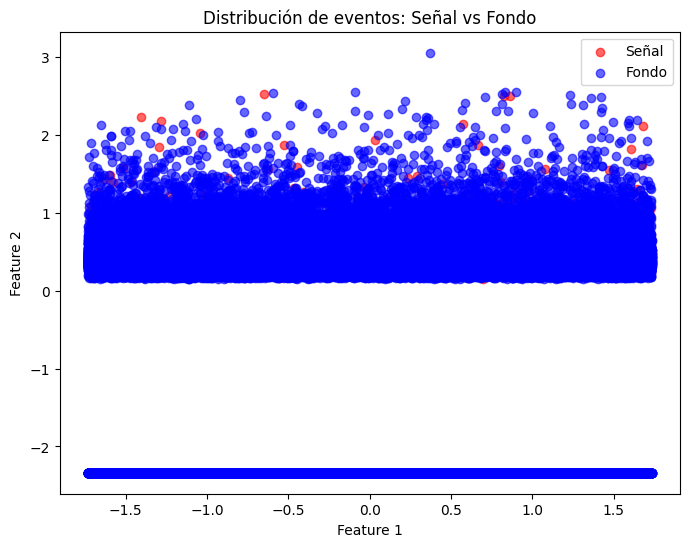

In [17]:

# VISUALIZACIÓN DE LOS DATOS

# Tomaremos solo las primeras dos características
X_plot = X_norm[:, :2]

# separar señal y fondo
signal = y == 1
background = y == 0

plt.figure(figsize=(8,6))

# puntos señal
plt.scatter(X_plot[signal,0],
            X_plot[signal,1],
            c='red',
            label='Señal',
            alpha=0.6)

# puntos fondo
plt.scatter(X_plot[background,0],
            X_plot[background,1],
            c='blue',
            label='Fondo',
            alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Distribución de eventos: Señal vs Fondo")

plt.legend()
plt.show()

/tmp/ipykernel_320/2714040162.py:13: OptimizeWarning: Unknown solver options: maxiter
  res_vis = optimize.minimize(


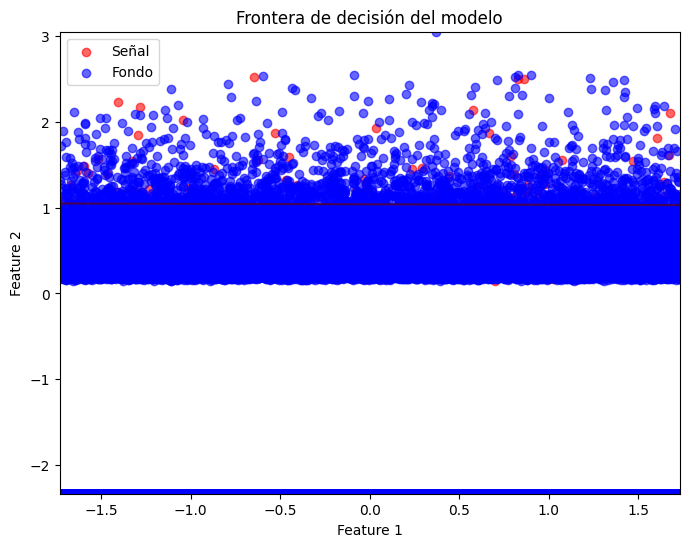

In [18]:
# FRONTERA DE DECISIÓN
# =====================================================

# usamos solo 2 variables para visualizar
X_vis = X_norm[:, :2]

# agregamos bias
X_vis = np.concatenate([np.ones((m,1)), X_vis], axis=1)

# entrenamos modelo solo para visualización
initial_theta_vis = np.zeros(X_vis.shape[1])

res_vis = optimize.minimize(
    fun=costFunction,
    x0=initial_theta_vis,
    args=(X_vis, y),
    jac=True,
    method='TNC',
    options={'maxiter':300}
)

theta_vis = res_vis.x


# graficamos los puntos otra vez
plt.figure(figsize=(8,6))

plt.scatter(X_plot[signal,0],
            X_plot[signal,1],
            c='red',
            label='Señal',
            alpha=0.6)

plt.scatter(X_plot[background,0],
            X_plot[background,1],
            c='blue',
            label='Fondo',
            alpha=0.6)

# crear grilla para la frontera
x1_vals = np.linspace(X_plot[:,0].min(), X_plot[:,0].max(), 100)
x2_vals = np.linspace(X_plot[:,1].min(), X_plot[:,1].max(), 100)

z = np.zeros((len(x1_vals), len(x2_vals)))

for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        z[i,j] = sigmoid(theta_vis[0] +
                         theta_vis[1]*x1_vals[i] +
                         theta_vis[2]*x2_vals[j])

# dibujar línea de decisión
plt.contour(x1_vals, x2_vals, z.T, levels=[0.5])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Frontera de decisión del modelo")

plt.legend()
plt.show()

In [19]:
# MATRIZ DE CONFUSIÓN

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_test)

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[29234  3603]
 [ 1491 15672]]


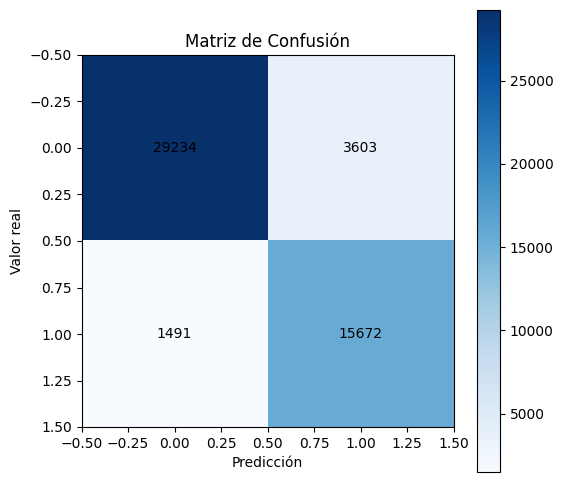

In [20]:
# GRÁFICO MATRIZ DE CONFUSIÓN

plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Matriz de Confusión")
plt.colorbar()

plt.xlabel("Predicción")
plt.ylabel("Valor real")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 color="black")

plt.show()

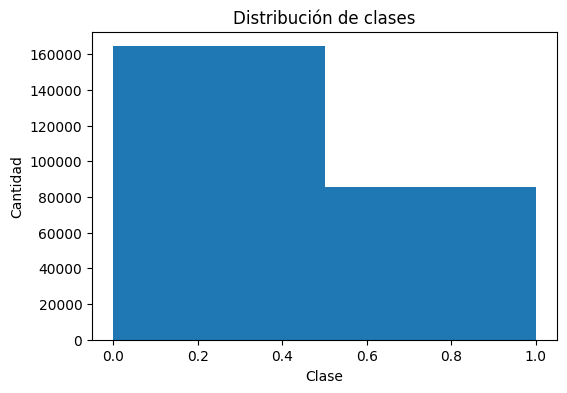

In [21]:
# DISTRIBUCIÓN DE CLASES

plt.figure(figsize=(6,4))

plt.hist(y, bins=2)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()